<a href="https://colab.research.google.com/github/shant-kolekar/dataAnalyticsEssentialModules/blob/main/matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resources
* To test Matplotlib skills click [here.](https://www.w3resource.com/graphics/matplotlib/#google_vignette)

* Good blog on Matplotlib usage with pandas. [click here](https://realpython.com/python-matplotlib-guide/)

* [**Matplotlib official doc**](https://matplotlib.org/stable/users/explain/quick_start.html#a-simple-example)

Matplotlib_Cheat_Sheet.jpg

# Dataset Description

## Student Performance Analysis
* This data project analyzes student achievement in Mathematics and Portuguese language, based on data from two Portuguese schools.
--------
### Assignment
* The purpose of this project is to delve into student data to uncover insights that could help understand and predict student success across different academic periods.
* As a contributor, you will explore the relationship between student grades and a myriad of demographic, social, and school-related factors. Your analysis will directly impact our ability to identify and address key influences on student performance.
----------------
### Your Tasks:
* Create Data Visualizations:

  * Generate histograms to observe the distribution of grades (G1, G2, G3) and other numerical factors like age and study time.
  * Construct box plots to spot outliers and understand the spread of the data.
  * Use bar charts to compare the average grades across different categories such as gender, parental education level, and internet access.
  * Your visualizations should help highlight trends and patterns that may influence student performance.

* Perform Statistical Tests:

  * Conduct Chi-Square Tests to investigate the association between categorical variables (e.g., gender, internet access) and student grades.    
  
  * For example, is there a statistical difference in grades between students with different levels of parental education?

    * Apply t-tests to compare the mean grades between two different groups, such as students from urban versus rural areas.

  * Use regression analysis to predict final grades based on various factors like study time and past failures.
  * Document your findings, interpret the p-values, and discuss the statistical significance of your results.

* Objectives:
  * Correlation Analysis: Determine which factors are most strongly correlated with student grades.
  * Predictive Modeling: Build a model that can predict a student's final grade based on their background and school-related activities.
  * Insight Generation: Provide actionable insights for schools to help improve student outcomes based on your findings.
----------
### Tools You Might Need:
* For Visualization: Matplotlib, Seaborn, or any other Python library that you are comfortable with.

* For Statistical Analysis: SciPy for conducting statistical tests, and statsmodels or Scikit-learn for any predictive modeling.

------------

## Data Description

The datasets, **student-mat.csv and student-por.csv**, include:

* School: The school attended by the student.
* Sex: Gender of the student.
* Age: Age of the student.
* Address: Urban or rural area of residence.
* Medu & Fedu: Parents' education level.
* Studytime: Weekly study time.
* Failures: Number of past class failures.
* G1, G2, G3: Grades in the first, second, and final periods.
Practicalities


>The data covers a wide range of factors, from personal demographics to academic records.
>Analyze the datasets to understand how these factors correlate with student performance in Mathematics and Portuguese language.


# Load Dataset into current Env

In [ ]:
por_dataset_id = '1iCfX9OZp_z3d7JXug36KGc3v1bwKcLV2'
mat_dataset_id = '1Z3HMmRmfd804dGgU_6XYthVY3VtqWPo5'

In [ ]:
import gdown

download_url = f'https://drive.google.com/uc?id={por_dataset_id}'
gdown.download(download_url, 'student-por.csv', quiet=False)

download_url = f'https://drive.google.com/uc?id={mat_dataset_id}'
gdown.download(download_url, 'student-mat.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1iCfX9OZp_z3d7JXug36KGc3v1bwKcLV2
To: /content/student-por.csv
100%|██████████| 93.2k/93.2k [00:00<00:00, 73.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Z3HMmRmfd804dGgU_6XYthVY3VtqWPo5
To: /content/student-mat.csv
100%|██████████| 57.0k/57.0k [00:00<00:00, 16.0MB/s]


'student-mat.csv'

# Beginning of Project

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
mat_df = pd.read_csv('student-mat.csv', delimiter=';')
por_df = pd.read_csv('student-por.csv', delimiter=';')

* `plt.subplots()` will create two objects when it is called without any args `fig` & `ax`. `fig`: is a container and `ax` is a canvas which contains all of data and on which we will draw.

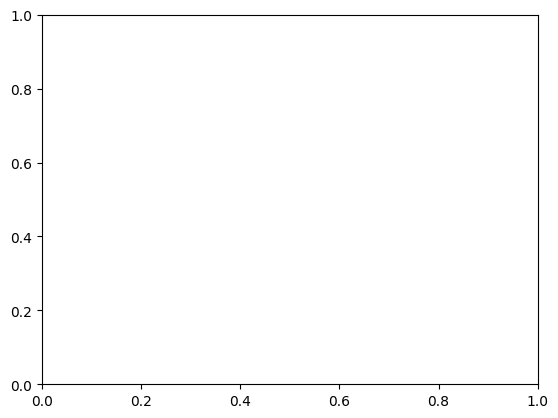

In [ ]:
fig, ax = plt.subplots()
plt.show()

## Exploring Dataset

In [ ]:
mat_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
por_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [ ]:
mat_df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

## Basic Plots

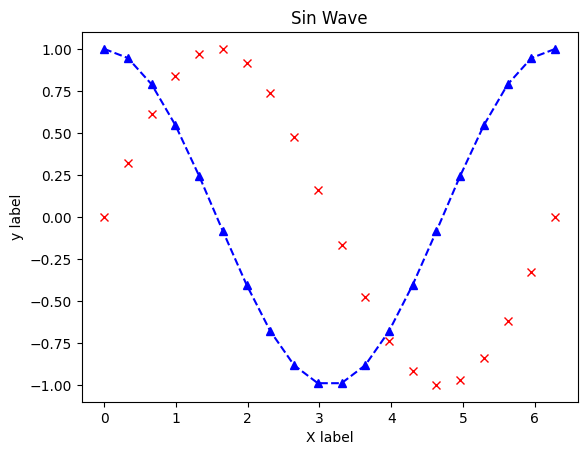

In [ ]:
# plotting starts

X = np.linspace(0, 2*np.pi, 20)
y = np.sin(X)
t = np.cos(X)
fig, ax = plt.subplots()

ax.plot(X
        , y
        , marker='x' # options: ['o', '.', '^']
        , linestyle='None' # options: ['-', '--']
        , color='r' # options: ['r' , 'g', 'b', 'y', 'k', 'w']
      )

# In same axes object we can add another plot
ax.plot(
    X
    , t
    , marker='^'
    , linestyle = '--'
    , color='b'
)



# Adding Customized Axes labels
ax.set_xlabel('X label')
ax.set_ylabel('y label')
ax.set_title('Sin Wave')


plt.show()

## Creating small multiples

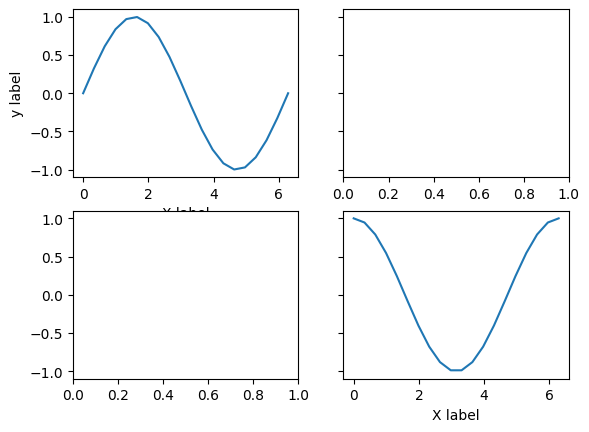

In [ ]:
fig, ax = plt.subplots(2,2 ,sharey=True)

ax[0,0].plot(X, y) #sin wave
ax[0,0].set_xlabel('X label')
ax[0,0].set_ylabel('y label')


ax[1,1].plot(X, t) #cos wave
ax[1,1].set_xlabel('X label')

plt.show()

* As We can see there is no data on axes so we can add data to each axes by using index.
  * For example we want to add two lines on 1st row, 1st col axes then we use following index : **`ax[0,0]`**

* If we had let's say only one column and multiple rows then we have to use only index of rows.
  * So we would use : **`ax[1]`** to add anything on 2nd row.

* Since y-axis have different ranges on every small multiples it's good to have same range  of y axis visible across each small multiples, by providing arg: **`sharey=True`** while intializing the object.